# EDA — Part 6: Mode homogeneity and relative frequencies

Maintained spatial-homogeneity analysis using the existing helper and 80% cumulative-frequency rule.


## Setup


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import geoplot as gplt

In [2]:
data = pd.read_csv("data/dataset.csv")
adjacent_counties = pd.read_csv('data/adjacent_counties.csv')

## Single-feature homogeneity


In [3]:
def get_mode(inp):
    return list(inp.value_counts().index)[0]

In [6]:
data.drop(columns = ['loc', 'h3']).groupby('fips').agg(get_mode)

,st_damcat,bldgtype,lc_type,clr,clr_cc
fips,,,,,
6001,RES,M,urban,cocoa,1
6003,RES,W,forest,tan,1
6005,RES,M,forest,coffee,1
6007,RES,W,urban+forest,brown,1
6009,RES,W,forest,cocoa,1
6011,RES,W,urban+crop,beige,1
6013,RES,W,urban+grass,brown,1
6015,RES,W,forest,verde,1
6017,RES,W,forest,brown,1


In [7]:
def bin_homogeneity(dataset, to_groupby = ['fips'], bins = ['lc_type', 'bldgtype']):
    totals = dataset.drop(columns = ['loc', 'h3']).groupby(to_groupby).count().rename(columns = {'st_damcat' : 'total'}).iloc[:, 0]
    relative_freq = dataset.drop(columns = ['loc', 'h3']).groupby(to_groupby + bins).count().reset_index().merge(totals, how = 'left', on = to_groupby)
    to_drop = [c for c in relative_freq.columns if c not in to_groupby + ['freq'] + bins]
    relative_freq = relative_freq.assign(freq = relative_freq[to_drop[0]] / relative_freq.total).drop(columns = to_drop).sort_values(by = to_groupby + ['freq'], ascending = False)
    def filter_cdf(col):
        _max = sum(np.cumsum(np.array(col.freq)) <= 0.8)
        _max = 1 if _max == 0 else _max
        return col[:_max]
    most_freq = relative_freq.groupby(to_groupby).apply(include_groups = False, func = filter_cdf).reset_index()
    most_freq = most_freq.drop(columns = [c for c in most_freq.columns if 'level' in c]).groupby('fips').count().rename(columns = {most_freq.columns[-1] : 'count'})
    most_freq = most_freq.drop(columns = [c for c in most_freq.columns if c != 'count'])
    return most_freq, relative_freq
    
bin_categories = ['lc_type', 'clr']
most, relative = bin_homogeneity(data, bins = bin_categories)

In [8]:
name_str = 'data/relative_frequencies'
for i in bin_categories:
    name_str += '_' + i
name_str += '.csv'
name_str
relative.set_index('fips').to_csv(name_str)

In [9]:
mosts = []
relative_freqs = []
features = []
for i in data.columns:
    if i in ['h3', 'loc', 'fips']:
        continue
    features.append(i)
    bin_categories = [i]
    most, freq = bin_homogeneity(data, to_groupby = ['fips'], bins = bin_categories)
    mosts.append(most)
    relative_freqs.append(freq)

## Pairwise homogeneity


In [10]:
for i in [['lc_type', 'bldgtype'], ['lc_type', 'clr'], ['clr', 'bldgtype']]:
    if i in ['h3', 'loc', 'fips']:
        continue
    bin_categories = i
    most, freq = bin_homogeneity(data, to_groupby = ['fips'], bins = bin_categories)
    mosts.append(most)
    relative_freqs.append(freq)
    features.append(i)

In [11]:
relative_freqs[2].columns[1]

'lc_type'

## Plots


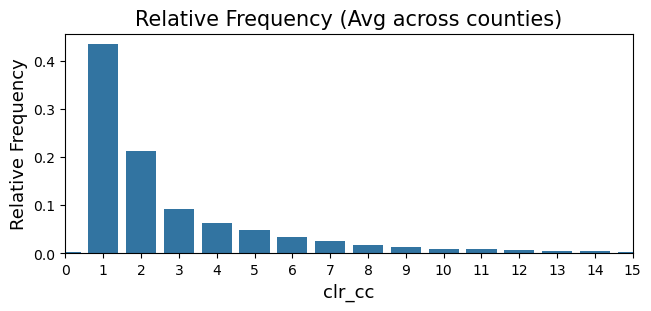

In [30]:
def visualize(i):
    f = plt.figure(constrained_layout=True)
    a = relative_freqs[i].groupby(features[i]).mean().freq
    visual = sns.barplot(x = np.array(a.index), y = np.array(a))
    visual.set_title('Relative Frequency (Avg across counties)', fontsize=15)
    plt.xlabel(relative_freqs[i].columns[1], fontsize = 13)
    plt.ylabel('Relative Frequency', fontsize=13)
    if relative_freqs[i].columns[1] == 'clr_cc':
        visual.set_xlim([0, 15])
    if relative_freqs[i].columns[1] == 'lc_type':
        visual.figure.set_figwidth(15)
    visual.figure.set_figheight(3)

    plt.savefig(f'images/relative_{features[i]}.png')

visualize(4)

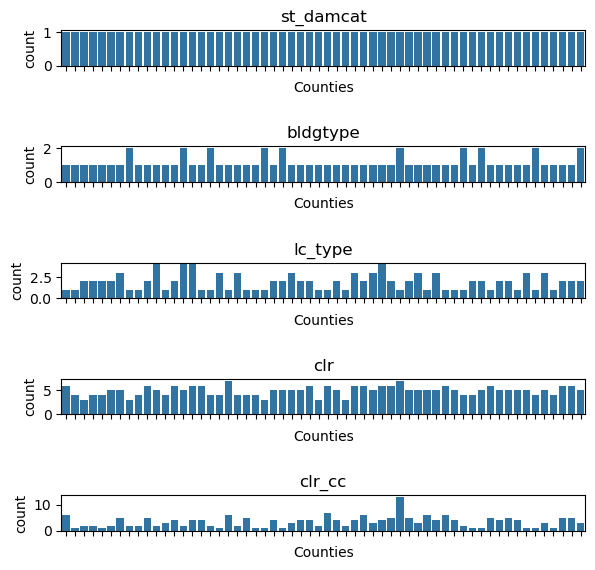

In [13]:
fig, ax = plt.subplots(5, 1)
for i in range(5):
    x_ = mosts[i].index
    y_ = mosts[i].iloc[:, 0]
    subplot = sns.barplot(x = x_, y = y_, ax = ax[i])
    subplot.set(title = features[i])
    subplot.set(xlabel = 'Counties')
    subplot.set(xticklabels = [])
fig.tight_layout() 
fig.set_figwidth(6)
fig.set_figheight(6)
plt.savefig('images/homogeneity.png')

## Moran's I


In [75]:
df = gpd.GeoDataFrame.from_file('morans_i_relative_browns_forest.csv', ignore_geometry = False)
df['geometry'] = gpd.GeoSeries.from_wkt(df['geometry'])
df = gpd.GeoDataFrame(df, geometry='geometry').assign(local = df.local.apply(float))
df

,fips,local,geometry
0,6063,0.580665,"POLYGON ((-121.36701 40.07767, -121.36701 40.0..."
1,6009,0.272696,"POLYGON ((-120.63093 38.3411, -120.63105 38.34..."
2,6027,0.668906,"POLYGON ((-118.33758 36.6548, -118.33683 36.65..."
3,6105,2.477840,"POLYGON ((-123.54396 40.73294, -123.54417 40.7..."
4,6003,1.232091,"POLYGON ((-120.07333 38.70109, -120.07332 38.7..."
5,6093,0.766167,"POLYGON ((-122.87087 42.00396, -122.87323 42.0..."
6,6049,-0.395585,"POLYGON ((-121.4489 41.47281, -121.44884 41.46..."
7,6005,0.340763,"POLYGON ((-121.02729 38.48136, -121.02729 38.4..."
8,6021,-0.217226,"POLYGON ((-122.89094 39.64488, -122.89094 39.6..."
9,6043,0.054343,"POLYGON ((-120.32153 37.5244, -120.32148 37.52..."


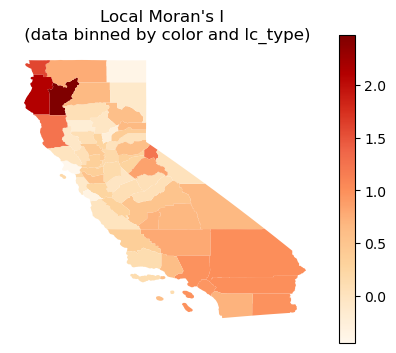

In [84]:

df.plot(column = 'local', cmap='OrRd', legend = True)
plt.rcParams["figure.figsize"] = (5,5)
plt.axis('off')
plt.title("Local Moran's I \n (data binned by color and lc_type)")
plt.savefig('images/morans_i_relative_browns_forest.png')

In [10]:
# using homogeneity counts for Bigquery analysis
name_str = 'data/eda'
for i in bin_categories:
    name_str += '_' + i
name_str += '_homogeneity.csv'
most = most.groupby(['fips']).count().rename(columns = {most.columns[-1] : 'count'})
most.drop(columns = [x for x in most.columns if x != 'count']).sort_values(by = 'count')

,count
fips,
6057,5
6003,5
6109,6
6045,7
6059,7
6063,7
6015,7
6075,8
6023,8


## Example county inspection


In [12]:
relative[np.array(relative.fips == 6023) | np.array(relative.fips == 6093) | np.array(relative.fips == 6105) | np.array(relative.fips == 6045) | np.array(relative.fips == 6015)].groupby(['fips', 'clr']).sum('freq').reset_index()

,fips,clr,freq
0,6015,alabaster,0.142143
1,6015,bar,0.005936
2,6015,beige,0.033739
3,6015,blue,0.004061
4,6015,coffee,0.284599
...,...,...,...
57,6105,maroon,0.001070
58,6105,olive,0.166934
59,6105,orange,0.093633
60,6105,plum,0.012306


In [11]:
adjacent_counties[adjacent_counties.county_code == 6023]

,geometry,county_code,neighbors_code
58,"POLYGON((-124.281397 40.799149, -124.28658 40....",6023,6105
59,"POLYGON((-124.281397 40.799149, -124.28658 40....",6023,6093
60,"POLYGON((-124.281397 40.799149, -124.28658 40....",6023,6045
61,"POLYGON((-124.281397 40.799149, -124.28658 40....",6023,6015


In [13]:
colors = relative[np.array(relative.fips == 6023) | np.array(relative.fips == 6093) | np.array(relative.fips == 6105) | np.array(relative.fips == 6045) | np.array(relative.fips == 6015)]
colors[colors.clr == 'verde']

,fips,lc_type,clr,freq
495,6015,forest,verde,0.247735
505,6015,urban+forest,verde,0.050609
